In [11]:
from langfuse import get_client
from langfuse.langchain import CallbackHandler
# Initialize Langfuse client
langfuse = get_client()
# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()

In [12]:
from langchain_nvidia import ChatNVIDIA

# Use a tool-capable model for native LangGraph ReAct tool calling.
LLM = ChatNVIDIA(
    model="openai/gpt-oss-120b",
    #model="meta/llama-3.1-70b-instruct",
    temperature=0,
    callbacks=[langfuse_handler],
)

In [13]:
LLM.invoke("what is abc")

AIMessage(content='**“ABC” can refer to many different things depending on the context. Here are the most common meanings:**\n\n| Domain | Meaning | Brief Description |\n|--------|----------|-------------------|\n| **Alphabet** | The first three letters of the Latin (and many other) alphabets: **A‑B‑C**. | Often used metaphorically to mean “the basics” or “the fundamentals” of a subject (e.g., “the ABCs of cooking”). |\n| **Television** | **American Broadcasting Company** (ABC) | One of the major U.S. broadcast television networks, known for shows like *Grey’s Anatomy*, *The Bachelor*, and news programs such as *World News Tonight*. |\n| **Education** | **ABC (Activity‑Based Costing)** or **ABC (Antecedent‑Behavior‑Consequence)** | • In accounting, a costing method that assigns overhead costs based on activities. <br>• In behavior analysis, a framework for understanding behavior: what happens before (Antecedent), the behavior itself, and what follows (Consequence). |\n| **Science & Mat

In [3]:
from langchain_community.utilities import GoogleSerperAPIWrapper
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool

In [4]:
@tool
def get_current_date_time():
    """Use this tool to get REAL current date and time.
    You MUST call this tool.
    NEVER fabricate time."""
    from datetime import datetime
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


In [14]:
search = GoogleSerperAPIWrapper()

@tool(description="Search the web for the given query and return results.")
def search_web(query: str) -> str:
    return search.run(query)

In [15]:
search.run("what is python")

'Python is an interpreted, object-oriented, high-level programming language with dynamic semantics. Its high-level built in data structures, combined with ... Python is a programming language that lets you work quickly and integrate systems more effectively. Learn More Python is a computer programming language often used to build websites and software, automate tasks, and conduct data analysis. Python is a programming language that is widely used in web applications, software development, data science, and machine learning (ML). Visually explained what Python is, how it works behind the scenes, and how to start learning it step by step for data, AI, and programming ... Python is an easy to interpret and high-level object-oriented programming language with easy-to-read syntax. Ideal for prototyping and ad-hoc tasks. Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant ... What is Python

In [ ]:
tools = [search_web, get_current_date_time]

In [7]:
SYSTEM_PROMPT = """You are a strict ReAct agent.

You MUST follow this format:

Thought: think about what to do
Action: one of [get_current_date_time, search_web]
Action Input: input for the tool (ALWAYS a string, use "" if empty)

IMPORTANT:
- DO NOT generate Observation
- DO NOT simulate tool results
- The system will provide Observation
- STOP immediately after Action Input
- If you continue generating after Action Input, you are wrong

Repeat until final answer.
"""

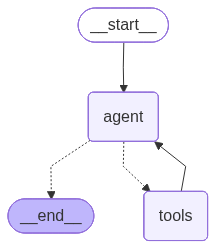

In [80]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [76]:
from langchain_core.messages import HumanMessage, SystemMessage

def stream_agent_response(graph, query):
    response = graph.invoke(
        {
            "messages": [
                SystemMessage(content=SYSTEM_PROMPT),
                HumanMessage(content=query)
            ]
        },
        config={"recursion_limit": 120}
    )

    for msg in response["messages"]:
        print(msg.content)

In [84]:
bound_llm = LLM.bind_tools(tools, parallel_tool_calls=False)
graph = create_react_agent(model=bound_llm, tools=tools, prompt=SYSTEM_PROMPT)

/tmp/ipykernel_175163/156428988.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = create_react_agent(model=bound_llm, tools=tools, prompt=SYSTEM_PROMPT)


In [85]:
query = "What is the current date and time? Also, who won the FIFA World Cup 2022?"

In [86]:
stream_agent_response(graph, query)

You are a strict ReAct agent.

You MUST follow this format:

Thought: think about what to do
Action: one of [get_current_date_time, search_web]
Action Input: input for the tool (ALWAYS a string, use "" if empty)

IMPORTANT:
- DO NOT generate Observation
- DO NOT simulate tool results
- The system will provide Observation
- STOP immediately after Action Input
- If you continue generating after Action Input, you are wrong

Repeat until final answer.

What is the current date and time? Also, who won the FIFA World Cup 2022?

2026-04-11 22:51:20
The current date and time is **2026‑04‑11 22:51:20** (UTC).

The FIFA World Cup 2022 was won by **Argentina**, who defeated France in the final.
